# Project 1

## Part 1: A discrete-time model

In [23]:
import numpy as np
import matplotlib.pyplot as plt

'''
States:
0: After surgery
1: Local recurrence
2: Distant metastasis
3: Local and distant recurrence
4: Death

One time step is 1 month. 

'''


# Transition matrix
P = np.array([[0.9915, 0.005, 0.0025, 0, 0.001], 
              [0, 0.986, 0.005, 0.004, 0.005], 
              [0, 0, 0.992, 0.003, 0.005], 
              [0, 0, 0, 0.991, 0.009], 
              [0, 0, 0, 0, 1]])

print("Transition Matrix P:\n")
print(P)

Transition Matrix P:

[[0.9915 0.005  0.0025 0.     0.001 ]
 [0.     0.986  0.005  0.004  0.005 ]
 [0.     0.     0.992  0.003  0.005 ]
 [0.     0.     0.     0.991  0.009 ]
 [0.     0.     0.     0.     1.    ]]


### Task 1

In [24]:
np.random.seed(5)

# Simulating 1000 woman
N = 1000
# States for all 1000 woman
states = np.zeros(N, dtype=int)
# All starting in state 0 (after surgery)
states[:] = 0
# Initialize a list to include state history (i.e. state-vector for each time step)
state_history = [states.copy()]
# Number of states
num_states = len(P)
# Initial time, starting in 1 to avoid having death at time 0
t = 1

# simulate until all women are in state 4 (death)
while not np.all(states == 4): 

    # Looping through all women
    for i in range(N):
        # current state for woman i
        current_state = states[i]

        # Only update state if this woman is not dead
        if current_state != 4:

            # Transition probabilities for current state
            transition_probs = P[current_state]
            # Next state 
            next_state = np.random.choice(num_states, p=transition_probs)
            # Update state for woman i
            states[i] = next_state
        
    # Increment in time after updating states for all women
    t += 1
    # Append current states to history
    state_history.append(states.copy())

# Print final time step
print(f"All women have died after {t} months ~ {t // 12} years and {t % 12} months.")


# Convert state history to a numpy array 
state_history = np.array(state_history)

print("State history shape:", state_history.shape)
#print("State history (last 5 time steps):\n", state_history[-5:])


All women have died after 1046 months ~ 87 years and 2 months.
State history shape: (1046, 1000)


(1000,)


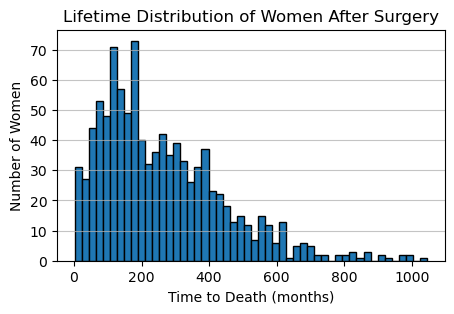

Mean death time (months): 259.737 ~ 21.0 years
Standard deviation of death time (months): 183.9528630682328 ~ 15.0 years


In [25]:
# Simmurizing the lifetime distribution of the women after surgery

# For every woman, find the time step at which she dies (state 4)
death_times = np.zeros(N, dtype=int)
for i in range(N):
    # Find the first time step for every woman (column) where the state = 4
    death_times[i] = np.where(state_history[:, i] == 4)[0][0]

# Should contain 1000 deaths times 
print(death_times.shape)

# Plotting the lifetime distribution
plt.figure(figsize=(5, 3))
plt.hist(death_times, bins=50, edgecolor='black')
plt.title('Lifetime Distribution of Women After Surgery')
plt.xlabel('Time to Death (months)')
plt.ylabel('Number of Women')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Mean death time (months):", np.mean(death_times), "~", np.mean(death_times) // 12, "years")
print("Standard deviation of death time (months):", np.std(death_times), "~", np.std(death_times) // 12, "years")



In [26]:
# In what proportion does cancer eventually reappear locally?

number_of_locally_recurrence = 0

# Count how many columns include a 1
for i in range(N):
    if np.any(state_history[:, i] == 1):
        number_of_locally_recurrence += 1

print(f"Number of women with local recurrence: {number_of_locally_recurrence}")
# Calculate the proportion
proportion_locally_recurrence = number_of_locally_recurrence / N
print(f"Proportion of women with local recurrence: {proportion_locally_recurrence:.2f}")

Number of women with local recurrence: 612
Proportion of women with local recurrence: 0.61


### Task 2

We let $\mathbf{p}_t$ denote the probability distribution over the states at time $t$. This distribution can be found by:

$$
\mathbf{p}_t = \mathbf{p}_0 (\mathbf{P}^t)
$$

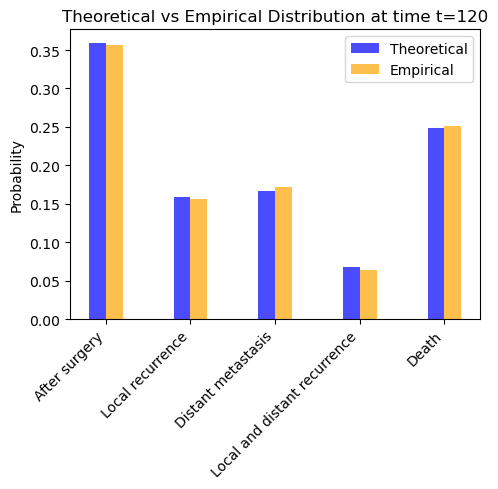

In [27]:
# Probability over states at time t = 120, i.e. p120

from scipy.stats import chisquare

# Initial distribution, i.e. p0
p0 = np.array([1, 0, 0, 0, 0])
# Distribution at time t = 120, i.e. p120
theoretical_p120 = p0 @ np.linalg.matrix_power(P, 120)

# Get the state vector at time t = 120, i.e. row number 120
states_120 = state_history[120, :]

# Calculate the empirical distribution at time t = 120
empirical_p120 = np.zeros(num_states)

for i in range(num_states):
    empirical_p120[i] = np.sum(states_120 == i) / N

#print(f"Theoretical distribution at time t=120: {theoretical_p120}")
#print(f"Empirical distribution at time t=120: {empirical_p120}")

# Plotting the theoretical and empirical distributions at time t = 120
labels = ['After surgery', 'Local recurrence', 'Distant metastasis', 'Local and distant recurrence', 'Death']
x = np.arange(num_states)
width = 0.2
plt.figure(figsize=(5, 5))
plt.bar(x - width/2, theoretical_p120, width, label='Theoretical', color='blue', alpha=0.7)
plt.bar(x + width/2, empirical_p120, width, label='Empirical', color='orange', alpha=0.7)
plt.ylabel('Probability')
plt.title('Theoretical vs Empirical Distribution at time t=120')
plt.xticks(x, labels, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
# Testing with chi-squared test if the empirical distribution at time t = 120 is significantly different from the theoretical distribution

# Count emperical frequencies of each state at time t = 120
observed_counts_120 = np.zeros(num_states, dtype=int)
for i in range(num_states):
    observed_counts_120[i] = np.sum(states_120 == i)

# Calculate expected counts based on the theoretical distribution at time t = 120
expected_counts_120 = theoretical_p120 * N

print(f"Observed counts at time t=120: {observed_counts_120}")
print(f"Expected counts at time t=120: {np.floor(expected_counts_120).astype(int)}\n")

chi2_stat, p_value = chisquare(observed_counts_120, expected_counts_120)

print(f"Chi-squared statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Observed counts at time t=120: [357 156 172  64 251]
Expected counts at time t=120: [359 158 166  67 248]

Chi-squared statistic: 0.5154
P-value: 0.9720


### Task 3

The above approach only validates simulation at a certain time point. Now we look at the emperical lifetime distribution - we can also express the theoretical life time distribution. 

The lifetime, $T$, follows a $\textit{discrete phase-type}$ distribution. The distribution has probability mass function:

$$
P(T=t) = \mathbf{\pi}(\mathbf{P_s}^t)\mathbf{p_s}
$$

and mean

$$
E(T)=\mathbf{\pi}(\mathbf{I-P_s})^{-1}\mathbf{1}
$$

where $\mathbf{\pi}$ is the distribution over states 1, 2, 3, 4 at time $t=0$. $\mathbf{P}_s$ is a $4 \times 4$ sub-matrix of $\mathbf{P}$ formed by removing the last row and column (corresponding to death). $\mathbf{p}_s$ is column vector indicating the probability of dying from states 1, 2, 3, 4. $\mathbf{1}$ is a vector of ones.

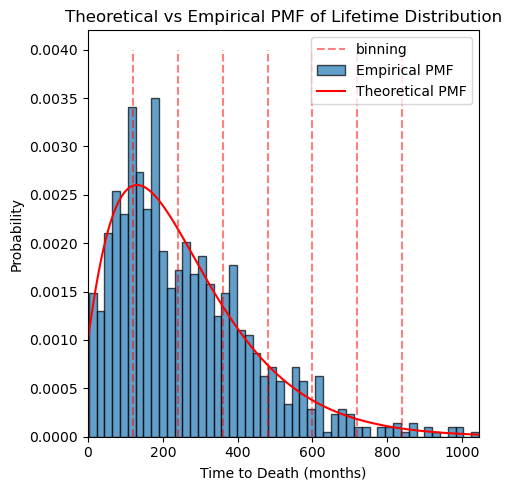

Theoretical mean lifetime: 262.37 months ~ 21.86 years
Empirical mean lifetime: 259.74 months ~ 21.64 years


In [29]:
pi = np.array([1, 0, 0, 0])

# Submatrix of transition matrix
Ps = np.array([[0.9915, 0.005, 0.0025, 0], 
              [0, 0.986, 0.005, 0.004], 
              [0, 0, 0.992, 0.003], 
              [0, 0, 0, 0.991]])
# Probability of dying from each state (except death state)
ps = np.array([0.001, 0.005, 0.005, 0.009])
# vector of ones
one = np.ones(len(Ps))

# time my simulation took
time_vector = np.arange(t)

# Theoretical pmf of lifetime distribution at time t
pmf_lifetime = np.array([
                        pi @ np.linalg.matrix_power(Ps, k) @ ps 
                        for k in time_vector
                        ])

# Theoretical mean lifetime
mean_lifetime = pi @ np.linalg.inv(np.eye(len(Ps)) - Ps) @ one
# Emperical mean lifetime
empirical_mean_lifetime = np.mean(death_times)

# Last death
max_time = np.max(death_times)

# Empirical pmf of lifetime distribution (frequency of deaths at each time step)
empirical_pmf = np.zeros(len(time_vector))
for k in time_vector:
    empirical_pmf[k] = np.sum(death_times == k) / N


# Plotting theoretical and empirical pmf of lifetime distribution
plt.figure(figsize=(5, 5))

#Edges to be used in second chi2 test
#Bin width of ten years
bin_width = 120
#8 ordinary bins
n_ord_bins = 7
edges2 = np.linspace(0, bin_width*n_ord_bins, n_ord_bins+1)

plt.vlines(edges2, 
          0, 
          0.004,
          label='binning',
          color='red',
          linestyles='--',
          alpha=0.5)

plt.hist(death_times, bins=50, density=True, alpha=0.7, label='Empirical PMF', edgecolor='black')
plt.plot(time_vector, pmf_lifetime, label='Theoretical PMF', color='red')
plt.xlabel('Time to Death (months)')
plt.ylabel('Probability')
plt.title('Theoretical vs Empirical PMF of Lifetime Distribution')
plt.xlim(0, max_time)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Theoretical mean lifetime: {mean_lifetime:.2f} months ~ {mean_lifetime / 12:.2f} years")
print(f"Empirical mean lifetime: {empirical_mean_lifetime:.2f} months ~ {empirical_mean_lifetime / 12:.2f} years")

In [30]:
support_start = 1

def pmf_T(k):
    """
    P(T = k)
    """
    k = int(k)

    if k < support_start:
        return 0.0

    exponent = k - support_start
    return float(pi @ np.linalg.matrix_power(Ps, exponent) @ ps)


def survival_T(k):
    """
    P(T >= k)
    """
    k = int(k)

    if k <= support_start:
        return 1.0

    exponent = k - support_start
    return float(pi @ np.linalg.matrix_power(Ps, exponent) @ one)


# Choose bins

# Each bin is [edges[i], edges[i+1])
# Final bin is [edges[-1], infinity)

edges = edges2


# Observed counts

def observed_counts(x, edges):
    extended_edges = np.append(edges, np.inf)
    counts, _ = np.histogram(x, bins=extended_edges)
    return counts


obs = observed_counts(death_times, edges)


# Expected counts

def expected_counts(edges, n):
    expected = []

    # Regular bins [a, b)
    for i in range(len(edges) - 1):
        a = edges[i]
        b = edges[i + 1]

        prob = survival_T(a) - survival_T(b)
        expected.append(n * prob)

    # Last bin [edges[-1], infinity)
    prob_tail = survival_T(edges[-1])
    expected.append(n * prob_tail)

    return np.array(expected)


exp = expected_counts(edges, N)

# Fix tiny numerical mismatch so sums agree exactly
exp = exp * np.sum(obs) / np.sum(exp)

# Chi square test

chi2_stat, p_value = chisquare(f_obs=obs, f_exp=exp)

print("Observed counts:")
print(obs)

print("\nExpected counts:")
print(exp)

print("\nSum observed:", np.sum(obs))
print("Sum expected:", np.sum(exp))

print("\nChi-squared statistic:", chi2_stat)
print("p-value:", p_value)

Observed counts:
[248 292 200 140  64  34  10  12]

Expected counts:
[245.59685459 294.41122223 210.35209314 123.73328084  65.51765173
  32.46449114  15.36577158  12.55863474]

Sum observed: 1000
Sum expected: 1000.0

Chi-squared statistic: 4.69761588729669
p-value: 0.6968087260620224


### Task 4

Estimate the expected lifetime after surgery of a woman who survives the frist 12 months following surgery, but whose breast cancer has also reappeared within the first 12 months, either locally or distant. 

Hint: Use rejection sampling. Simulate a number of women and discard all simulations that do not meet the requirements. Do this undtil you have reached 1000 acceptable simulations.

In [31]:
np.random.seed(5)

# Number of acceptable simulations 
N = 1000
# number of simulated women in total
num_sims = 0
# Counter for women meeting the criteria 
counter = 0
# List that includes all lifetimes for the acceptable simulations
lifetimes = []

while counter < N:
    # Incrementing number of simulations
    num_sims += 1
    # Simulating entire hitory of one woman
    state_hist = []
    # Starting in state 0 (after surgery)
    t = 1
    state = 0

    while state != 4: # Simulate until death
            # Transition probabilities for current state
            transition_probs = P[state]
            # Next state 
            next_state = np.random.choice(num_states, p=transition_probs)
            # Update state for woman i
            state = next_state
            state_hist.append(state)
            t += 1

            # when woman dies
            if state == 4: 

               # disregard this woman if she dies before 12 months
               if t < 12:
                    break

               # if woman survirves 12 months, check for recurrence before within the first 12 months
               if 1 in state_hist[:12] or 2 in state_hist[:12]:
                    counter += 1
                    life_time = t
                    lifetimes.append(life_time)

                    break # always break after death
            
print(f"Number of simulations needed to get {N} acceptable simulations: {num_sims}")                    
print(f"Number of acceptable simulations: {counter}")
print(f"Mean lifetime for acceptable simulations: {np.mean(lifetimes):.2f} months ~ {np.mean(lifetimes) / 12:.2f} years")

Number of simulations needed to get 1000 acceptable simulations: 12109
Number of acceptable simulations: 1000
Mean lifetime for acceptable simulations: 176.70 months ~ 14.72 years


### Task 5

What fraction die within the first 350 months? Answer this by simulating 200 women and record the fraction. Do this 100 times. Use control variates to reduce the variance.

How large a reduction in variance do you see, using control variates, as opposed to the crude Monte Carlo estimator?

In [32]:
# Number of total simulations
num_sims = 0
# List that includes 100 fractions for the acceptable simulations
fractions = []

LIFE = []

# Run the simulation 100 times
for i in range(100):
    print("Running simulation number:", i+1)
    # simulating 200 women

    # counter for women that die within the first 350 months
    counter = 0

    # death times for all 200 women
    death_times = []

    for j in range(200):

        # Starting in state 0 (after surgery)
        t = 1
        state = 0

        while state != 4: # Simulate until death
                # Transition probabilities for current state
                transition_probs = P[state]
                # Next state 
                next_state = np.random.choice(num_states, p=transition_probs)
                # Update state for woman i
                state = next_state
                t += 1

                # when woman dies
                if state == 4: 
                    death_times.append(t)

                # disregard this woman if she dies before 350 months
                    if t <= 350:
                        counter += 1
    print(f"Number of women that die within the first 350 months in simulation {i+1}: {counter}")
    # Calculate the fraction of women that die within the first 350 months
    fraction = counter / 200
    fractions.append(fraction)

    # Calculate the mean lifetime for this simulation
    mean_lifetime = np.mean(death_times)
    print(f"Mean lifetime for simulation {i+1}: {mean_lifetime:.2f} months ~ {mean_lifetime / 12:.2f} years\n")
    LIFE.append(mean_lifetime)


print("Mean fraction of women that die within the first 350 months the 100 simulations:")
print(np.mean(fractions))
print(f"Mean lifetime of all simulations:{np.mean(LIFE):.2f} months ~ {np.mean(LIFE) / 12:.2f} years")


Running simulation number: 1
Number of women that die within the first 350 months in simulation 1: 142
Mean lifetime for simulation 1: 266.78 months ~ 22.23 years

Running simulation number: 2
Number of women that die within the first 350 months in simulation 2: 154
Mean lifetime for simulation 2: 243.12 months ~ 20.26 years

Running simulation number: 3
Number of women that die within the first 350 months in simulation 3: 135
Mean lifetime for simulation 3: 289.58 months ~ 24.13 years

Running simulation number: 4
Number of women that die within the first 350 months in simulation 4: 149
Mean lifetime for simulation 4: 262.14 months ~ 21.84 years

Running simulation number: 5
Number of women that die within the first 350 months in simulation 5: 142
Mean lifetime for simulation 5: 294.95 months ~ 24.58 years

Running simulation number: 6
Number of women that die within the first 350 months in simulation 6: 150
Mean lifetime for simulation 6: 260.75 months ~ 21.73 years

Running simulati

In [33]:
#Control variate method
cov_matrix = np.cov(fractions, LIFE)
cov_xy = cov_matrix[0, 1]
c = -cov_xy / cov_matrix[1, 1]
true_mean_lifetime = mean_lifetime # from Task 2

# Control variate estimator
control_variate_estimator = fractions + c * (np.array(LIFE) - true_mean_lifetime)

#Variance of the crude Monte Carlo estimator
crude_mc_var = np.var(fractions, ddof=1)
# Variance of the control variate estimator
control_variate_var = np.var(control_variate_estimator, ddof=1)

# Reduction in variance
reduction_in_variance = (crude_mc_var - control_variate_var) / crude_mc_var

print(f"Covariance between fractions and lifetimes: {cov_xy:.4f}")
print(f"Variance of crude Monte Carlo estimator: {crude_mc_var:.4f}")
print(f"Variance of Control variate estimator: {control_variate_var:.4f}")
print(f"Reduction in variance: {reduction_in_variance}")

Covariance between fractions and lifetimes: -0.4752
Variance of crude Monte Carlo estimator: 0.0013
Variance of Control variate estimator: 0.0004
Reduction in variance: 0.6917952498910346


### Task 6

Discussed in Overleaf.

## Part 2: A continous-time model

### Task 7

Mean lifetime: 255.20 months ~ 21.27 years
Standard deviation of lifetime: 180.85 months ~ 15.07 years

95% confidence interval for mean lifetime: [243.99, 266.41] months ~ [20.33, 22.20] years
95% confidence interval for standard deviation of lifetime: [173.26, 189.15] months ~ [14.44, 15.76] years

Fraction of women with distant metastasis within first 30.5 months: 0.62


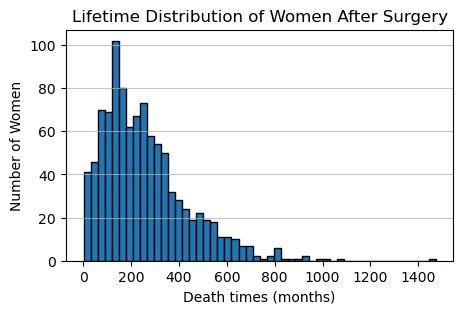

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.distributions import chi2

np.random.seed(5)

# Transition-rate matrix
Q = np.array([[-0.0085, 0.005, 0.0025, 0, 0.001], 
              [0, -0.014, 0.005, 0.004, 0.005], 
              [0, 0, -0.008, 0.003, 0.005], 
              [0, 0, 0, -0.009, 0.009], 
              [0, 0, 0, 0, 0]])

# Number of women to simulate
N = 1000
# List to store death times for all women
death_times = np.zeros(N, dtype=int)

# I simulate the entire state-history of each woman at a time

counter = 0

for i in range(N):
    
    t = 0
    state = 0

    # list for storing the state history of this woman
    state_hist = []
    # list for storing the time history of events for this woman
    time_hist = []

    while state != 4:
            # Sojourn time in current state
            sojourn_time = np.random.exponential(scale= -1 / Q[state, state])
            # Jumping to next event
            t += sojourn_time

            # Transition to next state 
            transition_probs = Q[state] / - Q[state, state]
            # but we cant transition to the same state, so we set that probability to zero
            transition_probs[state] = 0
            # Determine the next state
            next_state = np.random.choice(num_states, p=transition_probs) 
            
            # Update state
            state = next_state

            # Logging state and time history for this woman
            state_hist.append(state)
            time_hist.append(t)

            if state == 4:
                # logging the death time for this woman
                death_times[i] = t

                # mask for times more than 30.5 months
                mask = np.array(time_hist) > 30.5
                # check if there is distant metastasis (state 2 or 3) within the first 30.5 months
                if np.any(np.isin(np.array(state_hist)[mask], [2, 3])):
                    counter += 1


# Mean of lifetime
mean_lifetime = np.mean(death_times)
# Standard deviation for mean lifetime
std_lifetime = np.std(death_times, ddof=1)
# 95% confidence interval for mean lifetime
ci_lower = mean_lifetime - 1.96 * std_lifetime / np.sqrt(N)
ci_upper = mean_lifetime + 1.96 * std_lifetime / np.sqrt(N)
# 95% confidence interval for standard deviation of lifetime
ci_lower_std = std_lifetime * np.sqrt((N - 1) / chi2.ppf(0.975, N - 1))
ci_upper_std = std_lifetime * np.sqrt((N - 1) / chi2.ppf(0.025, N - 1))

print(f"Mean lifetime: {mean_lifetime:.2f} months ~ {mean_lifetime / 12:.2f} years")
print(f"Standard deviation of lifetime: {std_lifetime:.2f} months ~ {std_lifetime / 12:.2f} years\n")
print(f"95% confidence interval for mean lifetime: [{ci_lower:.2f}, {ci_upper:.2f}] months ~ [{ci_lower / 12:.2f}, {ci_upper / 12:.2f}] years")
print(f"95% confidence interval for standard deviation of lifetime: [{ci_lower_std:.2f}, {ci_upper_std:.2f}] months ~ [{ci_lower_std / 12:.2f}, {ci_upper_std / 12:.2f}] years\n")

print(f"Fraction of women with distant metastasis within first 30.5 months: {counter / N:.2f}")

# Plot the lifetime distribution
plt.figure(figsize=(5, 3))
plt.hist(death_times, bins=50, edgecolor='black')
plt.title('Lifetime Distribution of Women After Surgery')
plt.xlabel('Death times (months)')
plt.ylabel('Number of Women')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Task 8

The lifetime distribution now follows a continou time phase-type distribution. This has distribution function

$$
F_T(t)=1-\mathbf{p}_0 \text{exp}(\mathbf{Q}_st)\mathbf{1}
$$

$F_T(t)$ expresses the probability that the lifetime T is less than or equal to the time t.

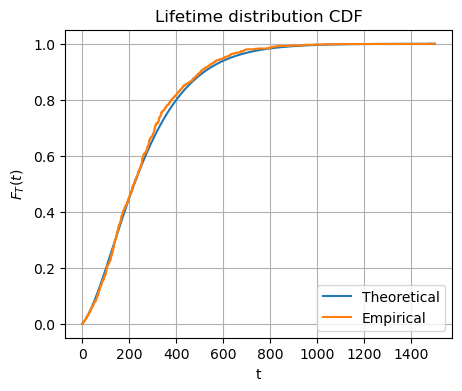

In [42]:
from scipy.linalg import expm

p0 = np.array([1, 0, 0, 0])

time = np.arange(0, 1500, 0.5)

# Submatrix of transition-rate matrix
Qs = np.array([[-0.0085, 0.005, 0.0025, 0], 
              [0, -0.014, 0.005, 0.004], 
              [0, 0, -0.008, 0.003], 
              [0, 0, 0, -0.009]])

one = np.ones(len(Qs))

# Compute theoretical F_T(t) for each t
F_T = np.array([
    1 - p0 @ expm(Qs * t) @ one
    for t in time
])

# Emperical CDF of lifetime distribution
empirical_cdf = np.array([
    np.mean(death_times <= t)
    for t in time
])

# Plot the CDF
plt.figure(figsize=(5, 4))
plt.plot(time, F_T, label="Theoretical")
plt.plot(time, empirical_cdf, label="Empirical")
plt.xlabel("t")
plt.ylabel(r"$F_T(t)$")
plt.title("Lifetime distribution CDF")
plt.grid(True)
plt.legend()
plt.show()

In [43]:
# Chi-squared test for goodness of fit

from scipy.stats import chisquare

# Choose bins
bin_width = 120
n_ord_bins = 7
edges = np.linspace(0, bin_width*n_ord_bins, n_ord_bins+1)
# Observed counts
observed_counts = np.zeros(n_ord_bins, dtype=int)
for i in range(n_ord_bins):
    observed_counts[i] = np.sum((death_times >= edges[i]) & (death_times < edges[i+1]))
# Expected counts
expected_counts = np.zeros(n_ord_bins)
for i in range(n_ord_bins):
    expected_counts[i] = N * (F_T[np.searchsorted(time, edges[i+1])] - F_T[np.searchsorted(time, edges[i])])
# Fix tiny numerical mismatch so sums agree exactly
expected_counts = expected_counts * np.sum(observed_counts) / np.sum(expected_counts)
# Chi-squared test
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)
print("Observed counts:")
print(observed_counts)
print("Expected counts:")
print(expected_counts)
print("Chi-squared statistic:")
print(chi2_stat)
print("P-value:")
print(p_value)


Observed counts:
[228 314 236 102  67  33  12]
Expected counts:
[249.46093487 294.50144605 210.23068013 123.85533975  65.75075566
  32.68047948  15.52036405]
Chi-squared statistic:
10.977870852889017
P-value:
0.08906277293538108


### Task 9

Kaplan-Meier estimator:

$$
\hat{S}(t) = \frac{N-d(t)}{N}
$$

where $d(t)$ is the number of women who have died at time $t$. 

In [44]:
# Transition-rate matrix after preventitive treatment
Q_treat = np.array([[0, 0.0025, 0.00125, 0, 0.001], 
                    [0, 0, 0, 0.002, 0.005], 
                    [0, 0, 0, 0.003, 0.005], 
                    [0, 0, 0, 0, 0.009], 
                    [0, 0, 0, 0, 0]])

# Fill diagonal using q_ii = -sum_{j != i} q_ij
np.fill_diagonal(Q_treat, -Q_treat.sum(axis=1))

# print sums for every row to check that they are zero
row_sums = Q_treat.sum(axis=1)
#print("Row sums of Q_treat (should be close to zero):", row_sums)
#print(Q_treat)


In [45]:
# Simulate 1000 women who have recieved the treatment. Plot the Kaplan-Meier estimate of the survival function.

N = 1000

# List to store death times for all women
death_times_treated = np.zeros(N, dtype=int)

counter = 0

for i in range(N):
    
    t = 0
    state = 0

    # list for storing the state history of this woman
    state_hist_treated = []
    # list for storing the time history of events for this woman
    time_hist_treated = []

    while state != 4:
            # Sojourn time in current state
            sojourn_time = np.random.exponential(scale= -1 / Q_treat[state, state])
            # Jumping to next event
            t += sojourn_time

            # Transition to next state 
            transition_probs = Q_treat[state] / - Q_treat[state, state]
            # but we cant transition to the same state, so we set that probability to zero
            transition_probs[state] = 0
            # Determine the next state
            next_state = np.random.choice(num_states, p=transition_probs) 
            
            # Update state
            state = next_state

            # Logging state and time history for this woman
            state_hist_treated.append(state)
            time_hist_treated.append(t)

            if state == 4:
                # logging the death time for this woman
                death_times_treated[i] = t


# Mean of lifetime
mean_lifetime = np.mean(death_times_treated)

print(f"Mean lifetime for treated women: {mean_lifetime:.2f} months ~ {mean_lifetime / 12:.2f} years")

Mean lifetime for treated women: 367.88 months ~ 30.66 years


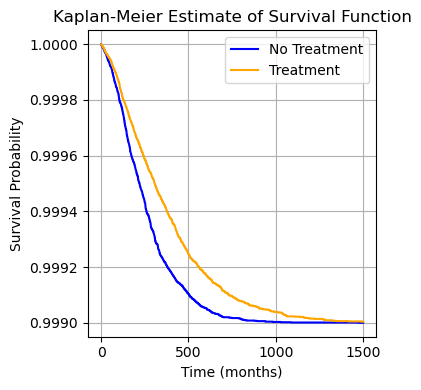

In [46]:
# Kaplan-Meier estimator of the survival function for women who have not received the treatment (i.e. I can use the simulation from Task 7)
KM_estimator_no_treatment = (N - empirical_cdf) / N 

# Kaplan-Meier estimator of the survival function for women who have received the treatment
empirical_cdf_treated = np.array([
                                np.mean(death_times_treated <= t)
                                for t in time
                                ])
KM_estimator_treatment = (N - empirical_cdf_treated) / N

# Plotting the Kaplan-Meier estimates for treated and untreated women
plt.figure(figsize=(4, 4))
plt.plot(time, KM_estimator_no_treatment, label='No Treatment', color='blue')
plt.plot(time, KM_estimator_treatment, label='Treatment', color='orange')
plt.xlabel('Time (months)')
plt.ylabel('Survival Probability')
plt.title('Kaplan-Meier Estimate of Survival Function')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Task 10 (Optional)

### Task 11

Discussed in Overleaf.

## Part 3: Estimation

We now want to estimate the transition-rate matrix. We assume that every woman is monitored every 4'th year (48 months). 

### Task 12

In [81]:
# Y_i = ((X(0), X(48), X(96), ...,)) i.e. we compute avector Y for every woman which contains states at every 48'th month. 
# The last value in Y for all women should be 4 (death).

np.random.seed(7)

# Transition-rate matrix
Q = np.array([[-0.0085, 0.005, 0.0025, 0, 0.001], 
              [0, -0.014, 0.005, 0.004, 0.005], 
              [0, 0, -0.008, 0.003, 0.005], 
              [0, 0, 0, -0.009, 0.009], 
              [0, 0, 0, 0, 0]])

# Number of women to simulate
N = 5
# List to store death times for all women
death_times = np.zeros(N, dtype=int)

Y = []

for i in range(N):
    
    t = 0
    state = 0

    # list for storing the state history of this woman
    state_hist = []
    # list for storing the time history of events for this woman
    time_hist = []

    while state != 4:
            # Sojourn time in current state
            sojourn_time = np.random.exponential(scale= -1 / Q[state, state])
            # Jumping to next event
            t += sojourn_time

            # Transition to next state 
            transition_probs = Q[state] / - Q[state, state]
            # but we cant transition to the same state, so we set that probability to zero
            transition_probs[state] = 0
            # Determine the next state
            next_state = np.random.choice(num_states, p=transition_probs) 
            
            # Update state
            state = next_state

            # Logging state and time history for this woman
            state_hist.append(state)
            time_hist.append(t)


    state_hist = np.array(state_hist)
    time_hist = np.array(time_hist)

    print(f"State history for woman {i}: {state_hist}")
    print(f"Time history for woman {i}: {time_hist}")

    # Subsampling every 48 months
    subsample_times = np.arange(0, time_hist[-1] + 48, 48)
    print(f"Subsample times for woman {i}: {subsample_times}")

    Y_i = []

    for tau in subsample_times:
        mask = time_hist <= tau # boolean mask for elements in time_hist that have happened before or at time tau

        if np.any(mask): # if mask contain any True
                Y_i.append(state_hist[mask][-1]) # last state before time tau
        else:
                Y_i.append(0) # if no events have happened before time tau, we are still in state 0
    print(f"Y_i for woman {i}: {Y_i}\n")

    Y.append(np.array(Y_i))
      

State history for woman 0: [2 4]
Time history for woman 0: [ 9.33845994 81.46119296]
Subsample times for woman 0: [ 0. 48. 96.]
Y_i for woman 0: [0, 2, 4]

State history for woman 1: [1 2 4]
Time history for woman 1: [448.96896609 498.63972484 537.71155541]
Subsample times for woman 1: [  0.  48.  96. 144. 192. 240. 288. 336. 384. 432. 480. 528. 576.]
Y_i for woman 1: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 4]

State history for woman 2: [2 3 4]
Time history for woman 2: [133.76834253 193.71270639 231.47735993]
Subsample times for woman 2: [  0.  48.  96. 144. 192. 240.]
Y_i for woman 2: [0, 0, 0, 2, 2, 4]

State history for woman 3: [1 2 4]
Time history for woman 3: [ 28.2372705  219.42577288 334.13376888]
Subsample times for woman 3: [  0.  48.  96. 144. 192. 240. 288. 336.]
Y_i for woman 3: [0, 1, 1, 1, 1, 2, 2, 4]

State history for woman 4: [1 2 4]
Time history for woman 4: [ 30.79508128 202.10275853 294.74077245]
Subsample times for woman 4: [  0.  48.  96. 144. 192. 240. 288. 336.]

### Task 13

Iteration 1: max diff = 0.037640
Iteration 2: max diff = 0.008790
Iteration 3: max diff = 7.011535
Iteration 4: max diff = 13.783598
Iteration 5: max diff = 20.818495
Iteration 6: max diff = 0.006931
Iteration 7: max diff = 0.004516
Iteration 8: max diff = 0.013700
Iteration 9: max diff = 0.008573
Iteration 10: max diff = 0.000656
Iteration 11: max diff = 0.005220
Iteration 12: max diff = 0.002304
Iteration 13: max diff = 0.002216
Iteration 14: max diff = 0.002545
Iteration 15: max diff = 0.002194
Iteration 16: max diff = 0.001174
Iteration 17: max diff = 0.003321
Iteration 18: max diff = 0.004811
Iteration 19: max diff = 0.000776
Iteration 20: max diff = 0.003263
Iteration 21: max diff = 0.003320
Iteration 22: max diff = 0.002637
Iteration 23: max diff = 0.000835
Iteration 24: max diff = 0.000866
Iteration 25: max diff = 0.001433
Iteration 26: max diff = 0.001514
Iteration 27: max diff = 0.000792
Iteration 28: max diff = 0.001112
Iteration 29: max diff = 0.001419
Iteration 30: max dif

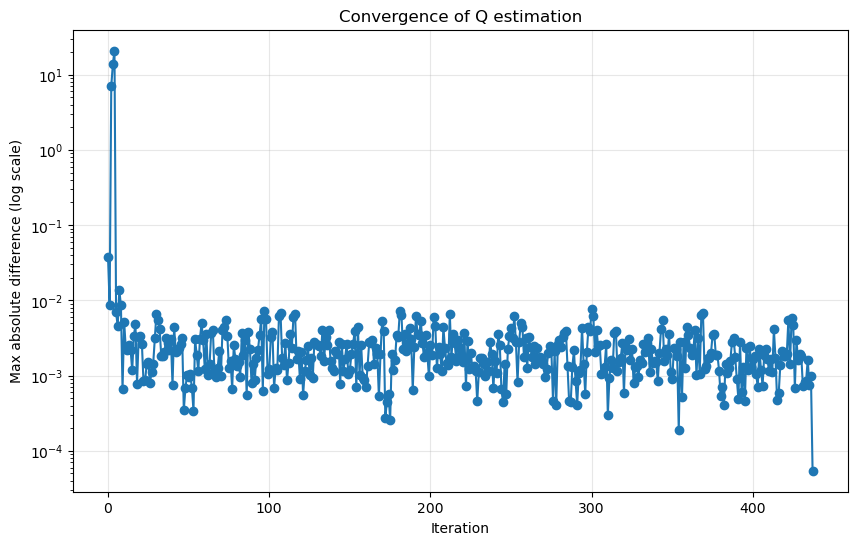

In [86]:
# Randomly inititate Q_est
Q_est = np.random.rand(5, 5) * 0.01
for i in range(5):
    Q_est[i, i] = -Q_est[i].sum() + Q_est[i, i]

max_iter = 500
tol = 1e-4
diffs = []

for iteration in range(max_iter):
    N = np.zeros((5, 5)) # total number of jumps for all women from state i to j
    S = np.zeros(5) # total time spent in state i for all women

    # looping through all statehistories in Y for every woman
    for obs in Y:

        # Step 1: simulate a trajectory that maches the observed states (every 48 months) (elements in Y)
        for k in range(len(obs) - 1):
            start = obs[k]  # state i
            end   = obs[k + 1]  # state i + 1

            accepted = False

            while not accepted:
                current_state = start
                time = 0.0
                jump_times = []
                jump_states = []

                while time < 48 and current_state != 4:
                    rate = -Q_est[current_state, current_state]
                    state_time = np.random.exponential(1 / rate)

                    if time + state_time > 48: # we only stay in this interval for 48 months
                        break

                    time += state_time
                    p = Q_est[current_state].copy() / rate
                    p[current_state] = 0.0
                    next_state = np.random.choice(num_states, p=p)

                    jump_times.append(time)
                    jump_states.append(next_state)
                    current_state = next_state
                # Checking if observed state at time 48 (end) is the same as the simulated state at time 48 (current_state)
                if current_state == end:
                    accepted = True

            prev_t = 0.0
            current = start

            # Step 2: Update S and N
            for t, s in zip(jump_times, jump_states):
                S[current] += t - prev_t
                N[current, s] += 1
                current = s
                prev_t = t

            S[current] += 48 - prev_t

    # Step 3: Update Q_est
    Q_new = np.zeros((5, 5))
    for i in range(5):
        for j in range(5):
            if i != j and S[i] > 0:
                Q_new[i, j] = N[i, j] / S[i]
        Q_new[i, i] = -Q_new[i].sum()

    diff = np.max(np.abs(Q_new - Q_est))
    diffs.append(diff)
    print(f"Iteration {iteration + 1}: max diff = {diff:.6f}")

    if diff < tol:
        print("Converged!")
        Q_est = Q_new
        break

    Q_est = Q_new

print("\nEstimated Q:")
print(Q_est)
print("\nTrue Q:")
print(Q)

plt.figure(figsize=(10, 6))
plt.plot(diffs, marker='o')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Max absolute difference (log scale)')
plt.title('Convergence of Q estimation')
plt.grid(True, alpha=0.3)
plt.show()